In [39]:
import numpy as np
import pandas as pd
import pickle
from sklearn import datasets
import matplotlib.pyplot as plt

# Przygotowanie danych

In [2]:
data_breast_cancer = datasets.load_breast_cancer(as_frame=True)
print(data_breast_cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

<Axes: xlabel='x', ylabel='y'>

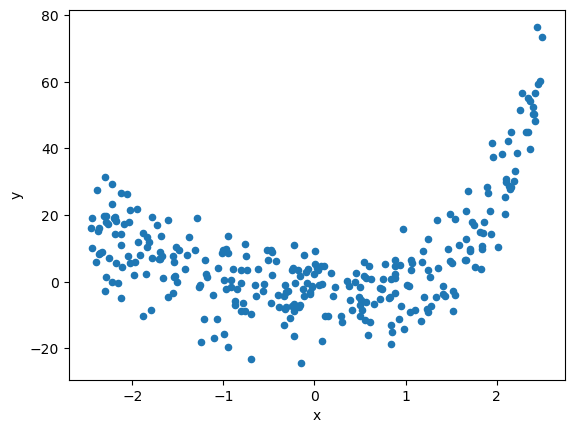

In [3]:
size = 300
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})
df.plot.scatter(x='x',y='y')

# Klasyfikacja DT

In [4]:
from sklearn.tree import DecisionTreeClassifier

## GridSearchCV

In [5]:
X_bc = data_breast_cancer.data[['mean texture', 'mean symmetry']]
y_bc = data_breast_cancer.target

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size = 0.2, random_state = 42)

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, mean_squared_error as MSE

In [9]:
tree_clf = DecisionTreeClassifier(random_state=42)

In [10]:
param_grid = {'max_depth': range(1, 15)}

In [11]:
search = GridSearchCV(estimator=tree_clf, param_grid=param_grid, scoring='f1', cv=5)
search.fit(X_bc, y_bc)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': range(1, 15)}, scoring='f1')

In [12]:
search.best_params_

{'max_depth': 2}

## Trening

In [13]:
clf = DecisionTreeClassifier(max_depth=search.best_params_['max_depth'], random_state=42)

In [14]:
clf.fit(X_bc_train, y_bc_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

## Graf

In [15]:
from sklearn import tree

In [16]:
dot_data = tree.export_graphviz(clf,
                                feature_names=['mean texture', 'mean symmetry'],
                                class_names=['Malignant', 'Benign'],
                                rounded=True,
                                filled=True)

In [17]:
import graphviz

In [18]:
graph = graphviz.Source(dot_data) 

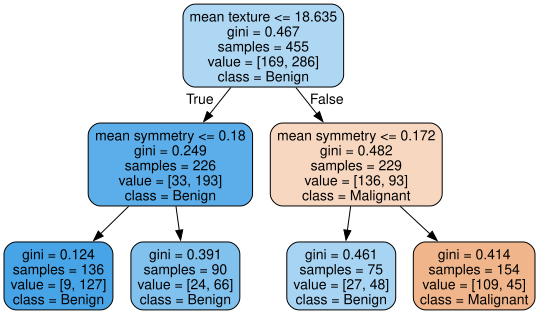

In [19]:
graph

In [20]:
graph.render("bc", format='png')

'bc.png'

## Wyniki

In [21]:
results = [clf.max_depth,
           f1_score(y_bc_train, clf.predict(X_bc_train)),
           f1_score(y_bc_test, clf.predict(X_bc_test)),
           accuracy_score(y_bc_train, clf.predict(X_bc_train)),
           accuracy_score(y_bc_test, clf.predict(X_bc_test))]

In [22]:
with open('f1acc_tree.pkl', 'wb') as f:
    pickle.dump(results, f)

# Regresja DT

In [23]:
from sklearn.tree import DecisionTreeRegressor

## GridSearchCV

In [24]:
X_train, X_test, y_train, y_test = train_test_split(df['x'], df['y'], test_size=0.2, random_state=42)

In [25]:
param_grid = {'max_depth': range(1, 100)}

In [26]:
tree_reg = DecisionTreeRegressor(random_state=42)

In [27]:
search = GridSearchCV(estimator=tree_reg, param_grid=param_grid, scoring='neg_mean_squared_error')
search.fit(X.reshape(-1,1), y)

GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': range(1, 100)},
             scoring='neg_mean_squared_error')

## Treni

In [28]:
reg = DecisionTreeRegressor(max_depth=search.best_params_['max_depth'], random_state=42)

In [29]:
reg.fit(X_train.values.reshape(-1,1), y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

## Graf

In [30]:
dot_data = tree.export_graphviz(reg,
                                rounded=True,
                                filled=True)

In [31]:
graph = graphviz.Source(dot_data) 

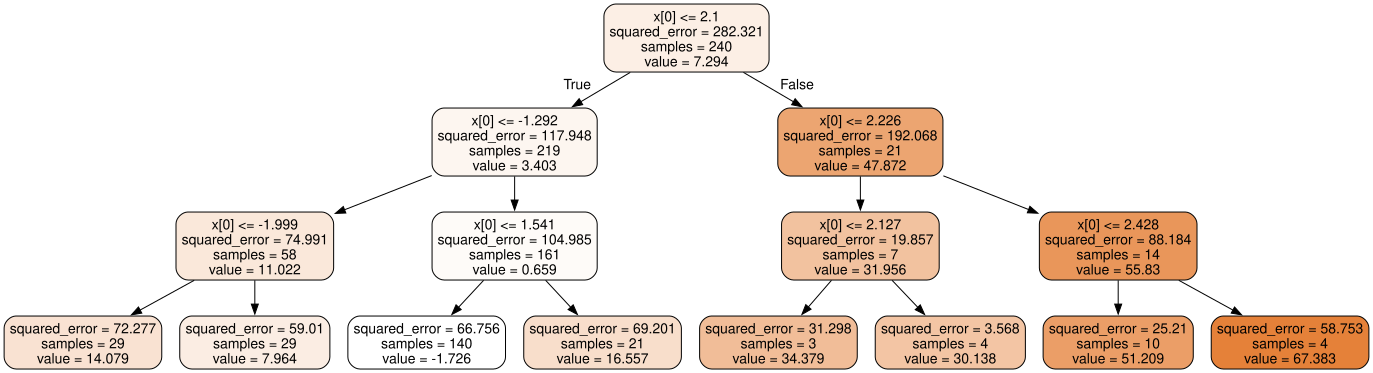

In [32]:
graph

In [33]:
graph.render('reg', format='png')

'reg.png'

## Wyniki

In [34]:
results = [reg.max_depth,
           MSE(y_train, reg.predict(X_train.values.reshape(-1,1))),
           MSE(y_test, reg.predict(X_test.values.reshape(-1,1)))]

In [35]:
with open('mse_tree.pkl', 'wb') as f:
    pickle.dump(results, f)

In [37]:
MSE(y_train, reg.predict(X_train.values.reshape(-1,1))), MSE(y_test, reg.predict(X_test.values.reshape(-1,1)))

(63.34003756636606, 73.23751534235929)

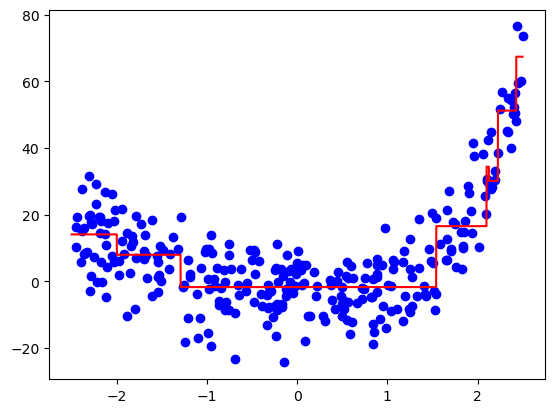

In [40]:
plt.clf()
plt.scatter(X, y, c="blue")
X_new1 = np.arange(-2.5, 2.5, 0.001).reshape(-1,1)
plt.plot(X_new1, reg.predict(X_new1), c="red")
plt.show()